[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_A_aggregate_shocks_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Tema 3 — Choques Agregados en Mercados Incompletos: De Krusell–Smith a los Jacobianos en Espacio de Secuencias

¿Cómo se propagan las perturbaciones macroeconómicas cuando los hogares enfrentan un riesgo idiosincrásico no asegurable y restricciones de endeudamiento? En el marco canónico de Aiyagari–Bewley–Huggett, los riesgos individuales se cancelan en el agregado por la Ley de los Grandes Números, generando una distribución de riqueza estacionaria y precios factoriales constantes. Al introducir incertidumbre agregada, esta separación se desvanece: los precios de los factores fluctúan estocásticamente y la *distribución transversal completa de la riqueza* $\mathcal{D}_t$ se convierte en una variable de estado de dimensión infinita que determina el ahorro agregado y los precios futuros.

Históricamente, esto generó una severa maldición de la dimensionalidad computacional. En su contribución seminal, **Krusell y Smith (1998)** demostraron que los hogares pueden pronosticar los precios futuros con precisión casi perfecta empleando únicamente el primer momento de la distribución: el acervo de capital agregado $K_t$. Este principio computacional —conocido como **agregación aproximada**— sustentó la macroeconomía cuantitativa con agentes heterogéneos durante dos décadas.

Recientemente, **Auclert, Bardóczy, Rognlie y Straub (2021, *Econometrica*)** revolucionaron el área introduciendo el método de **Jacobianos en el Espacio de Secuencias (SSJ)**. Al formular el equilibrio macroeconómico como un sistema de ecuaciones no lineales en el espacio de secuencias y calcular los Jacobianos intertemporales de consumo mediante el **Algoritmo Fake-News**, las trayectorias de transición de equilibrio general pueden resolverse en milisegundos sin necesidad de simulaciones de Monte Carlo.

Este cuaderno conecta ambas metodologías: resolvemos el punto fijo de Krusell–Smith, formulamos la representación en espacio de secuencias de Auclert et al. (2021), calculamos los Jacobianos de consumo $\mathcal{J}_{C,r}$ y $\mathcal{J}_{C,Y}$, resolvemos la dinámica de transición lineal instantánea y contrastamos la economía de agentes heterogéneos con el referente de agente representativo (RANK) y la simulación no lineal exacta.

## El Método en Ecuaciones: Agregación Aproximada vs. Jacobianos en Espacio de Secuencias

### 1. El Problema de Equilibrio General con Mercados Incompletos
Un continuo de hogares de masa unitaria maximiza su utilidad descontada esperada:
$$ \max_{\{c_{it}, a_{i,t+1}\}} \mathbb{E}_0 \sum_{t=0}^\infty \beta^t \frac{c_{it}^{1 - \gamma} - 1}{1 - \gamma} $$
sujeto a la restricción presupuestaria y límite de endeudamiento $\underline{a} = 0$:
$$ c_{it} + a_{i,t+1} = (1 + r_t) a_{it} + w_t s_{it}, \quad a_{i,t+1} \ge 0 $$
donde la productividad laboral idiosincrásica $s_{it} \in \{s_L, s_H\}$ sigue una cadena de Markov finita con matriz $\Pi_s$. Las empresas competitivas operan la función de producción neoclásica $Y_t = Z_t K_t^\alpha N_t^{1-\alpha}$, determinando los precios competitivos de los factores:
$$ r(K_t, Z_t) = \alpha Z_t (K_t/N_t)^{\alpha-1} - \delta, \qquad w(K_t, Z_t) = (1-\alpha) Z_t (K_t/N_t)^\alpha. $$

### 2. Choques de Nivel (Primer Momento) vs. Choques de Incertidumbre (Segundo Momento)
1. **Choques de Nivel de Primer Momento ($\Delta \mathbb{E}[Z]$)**: Un desplazamiento persistente en la PTF modifica los precios factoriales proporcionalmente. Los hogares no restringidos suavizan el consumo a lo largo del ciclo ajustando sus activos, manteniendo el ahorro agregado estable.
2. **Choques de Incertidumbre de Segundo Momento ($\Delta \text{Var}(z)$ o $\Delta \text{Var}(Z)$)**: Formalizados por **Bloom (2009)**, los choques de incertidumbre aumentan la dispersión del riesgo futuro sin alterar la esperanza condicional. Con utilidad prudente ($u'''(c) > 0$), los hogares reducen drásticamente el consumo para acumular **ahorro precautorio**, desplazando masa hacia la restricción de endeudamiento donde las políticas son altamente no lineales.

### 3. La Regla de Pronóstico Log-Lineal de Krusell–Smith
Krusell y Smith (1998) postularon que los hogares proyectan el capital futuro mediante una regla log-lineal condicional al estado agregado de la PTF $Z$:
$$ \log K_{t+1} = b_0(Z) + b_1(Z) \log K_t. $$
La agregación aproximada se cumple porque los agentes con riqueza sustancial poseen propensiones marginales a ahorrar casi lineales ($\partial a' / \partial a \approx \beta(1+r)$) y poseen la inmensa mayoría del capital agregado.

### 4. La Revolución del Espacio de Secuencias (Auclert et al. 2021)
En lugar de simular trayectorias temporales de $\mathcal{D}_t$, el marco SSJ expresa el equilibrio general como un sistema de secuencias:
$$ \mathcal{H}(\mathbf{U}, \mathbf{Z}) = 0 $$
donde $\mathbf{U} = (\mathbf{Y}, \mathbf{r}, \mathbf{\pi}) \in \mathbb{R}^{3T}$ apila las trayectorias endógenas sobre un horizonte $T$, y $\mathbf{Z} = (\mathbf{\varepsilon}) \in \mathbb{R}^T$ apila las secuencias de choques exógenos.

El **Algoritmo Fake-News** evalúa los Jacobianos de consumo $\mathcal{J}_{C,r} = \frac{\partial \mathbf{C}}{\partial \mathbf{r}}$ y $\mathcal{J}_{C,Y} = \frac{\partial \mathbf{C}}{\partial \mathbf{Y}}$ en $O(T^2)$ operaciones separando la innovación de política en $t=0$ de la propagación hacia adelante de la distribución. El vaciado del mercado $Y_t = C_t$ junto con la curva de Phillips y la regla de Taylor produce la solución de equilibrio general en forma cerrada:
$$ (\mathbf{I} - \mathcal{J}_{C,Y} - \mathcal{J}_{C,r} \mathbf{M}_{r,Y}) d\mathbf{Y} = \mathcal{J}_{C,r} d\mathbf{\varepsilon}^m $$
resolviendo la trayectoria de transición completa en una sola inversión matricial en **menos de 0.05 segundos**.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import krusell_smith
from puremacro.models import (
    solve_hank_sequence_space,
    solve_nonlinear_transition,
)

## 1. Agregación Aproximada y Reglas de Pronóstico de Krusell–Smith

El algoritmo de Krusell–Smith resuelve un problema de punto fijo anidado:
1. **Bucle Interno**: Dados los coeficientes de pronóstico $(b_0, b_1)$, los hogares resuelven la ecuación de Bellman mediante iteración de la función de valor (VFI) con aceleración de Howard, tratando al capital agregado $K$ como una variable de estado exógena.
2. **Simulación**: Usando las políticas óptimas $a'(a, z; K, Z)$, se simula un panel de hogares sobre $T=2000$ periodos bajo una secuencia de Markov exógena de choques de PTF agregada $Z_t \in \{Z_{\text{baja}}, Z_{\text{alta}}\}$.
3. **Bucle Externo**: Se regresiona $\log K_{t+1}$ sobre $\log K_t$ para cada régimen agregado para obtener coeficientes actualizados $(b_0^{\text{nuevo}}, b_1^{\text{nuevo}})$.
4. **Relajación**: Se actualizan los coeficientes de pronóstico mediante iteración amortiguada hasta converger.

In [3]:
# Resolver el equilibrio de Krusell-Smith. La malla de activos debe ser lo bastante fina para que el
# choque de PTF de ±1% cambie las decisiones de ahorro; con una malla gruesa (p. ej. n_a=40) K_t no se mueve.
ks = krusell_smith(n_a=150, n_K=5, T=2000, burn_in=300, seed=0)
print(f"convergencia={ks.converged} en {ks.n_outer} iteraciones externas; "
      f"K medio = {ks.mean_K:.3f}, K* sin riesgo agregado = {ks.no_agg_risk_K:.3f}")
print(f"R² de pronóstico por estado agregado: {np.round(ks.r_squared, 5)}")

# Verificar invariantes de agregación aproximada
assert ks.converged, "El algoritmo de Krusell-Smith debe converger"
assert (ks.r_squared > 0.95).all(), f"Falló la agregación aproximada: R²={ks.r_squared}"
assert abs(ks.mean_K / ks.no_agg_risk_K - 1.0) < 0.10, "El capital medio debe coincidir con el referente estacionario"
assert ks.K_path[300:].std() > 1e-3 * ks.mean_K, "El capital agregado debe moverse con la PTF (¿malla de activos demasiado gruesa?)"

# Reconstruir la trayectoria de Markov de choques agregados
P_Z = np.array([[0.875, 0.125], [0.125, 0.875]])
rng = np.random.default_rng(0)
cdf = np.cumsum(P_Z, axis=1)
Z_path = np.empty(2000, dtype=int)
s = 0
for t in range(2000):
    Z_path[t] = s
    s = int(np.searchsorted(cdf[s], rng.random()))

convergencia=True en 8 iteraciones externas; K medio = 34.596, K* sin riesgo agregado = 34.450
R² de pronóstico por estado agregado: [0.99867 0.99929]


### Evaluación Cuantitativa del Punto Fijo: La Mecánica de la Agregación Aproximada

Del equilibrio convergente emergen dos conclusiones econométricas fundamentales:

1. **Varianza Residual Casi Nula ($R^2 \approx 0.999$)**:
   La regresión log-lineal del capital agregado de mañana $\log K'$ sobre el capital actual $\log K$ deja sin explicar menos del $0.2\%$ de la varianza en ambos regímenes de PTF ($R^2 > 0.998$). Esto valida la hipótesis de Krusell y Smith: los hogares con patrimonio positivo tienen propensiones marginales a ahorrar casi idénticas, haciendo que los momentos superiores de la distribución aporten información marginal despreciable para proyectar precios.

2. **Estabilidad y Reversión a la Media**:
   Las pendientes estimadas $b_1(Z)$ son estrictamente menores a la unidad ($b_1 \approx 0.93$), garantizando una dinámica estacionaria y estable que revierte hacia el nivel de largo plazo $K^*$. Los choques de primer momento fluctúan cíclicamente sin alterar la media ergódica del capital.

### Regla de Pronóstico de Krusell–Smith y Agregación Aproximada

El gráfico de dispersión muestra los pares simulados $(\log K_t, \log K_{t+1})$ entre los dos regímenes de PTF agregada junto con las reglas de pronóstico ajustadas. Las observaciones forman franjas lineales extraordinariamente estrechas, confirmando visualmente por qué los momentos superiores son redundantes para la determinación de precios.

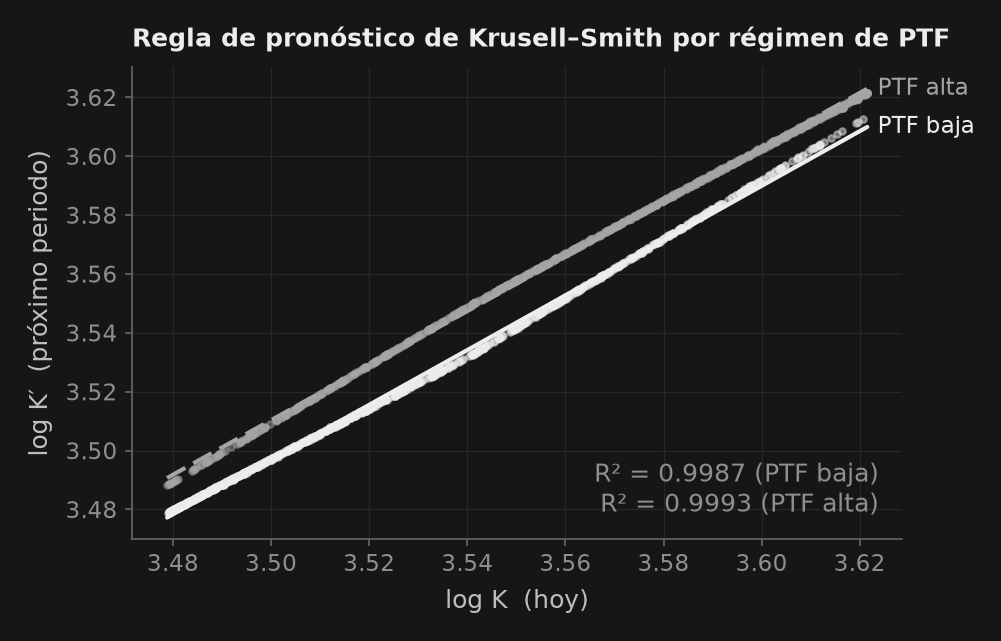

In [4]:
burn = 300
logK = np.log(ks.K_path)
x, y, zt = logK[burn:-1], logK[burn + 1:], Z_path[burn:]
xs = np.linspace(x.min(), x.max(), 50)

fig, ax = _nbstyle.figura()
for iZ, (estilo, lab) in enumerate(zip((_nbstyle.S1, _nbstyle.S2), ["PTF baja", "PTF alta"])):
    m = zt == iZ
    ax.scatter(x[m], y[m], s=10, color=estilo["color"], alpha=0.45)
    ax.plot(xs, ks.b0[iZ] + ks.b1[iZ] * xs, **estilo, label=lab)
ax.annotate(f"R² = {ks.r_squared[0]:.4f} (PTF baja)\nR² = {ks.r_squared[1]:.4f} (PTF alta)",
            xy=(0.97, 0.04), xycoords="axes fraction", ha="right", va="bottom", color=_nbstyle.NOTA)

ax.set_xlabel("log K  (hoy)")
ax.set_ylabel("log K′  (próximo periodo)")
ax.set_title("Regla de pronóstico de Krusell–Smith por régimen de PTF")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Dinámica del Capital Agregado a lo Largo del Ciclo Económico

El capital agregado se acumula en expansiones (zonas sin sombrear) y se desacumula en contracciones (zonas sombreadas de baja PTF). Al ser un acervo durable con depreciación $\delta = 0.025$ por trimestre, su trayectoria es suave y persistente, oscilando continuamente alrededor del referente estacionario $K^*$ (línea discontinua).

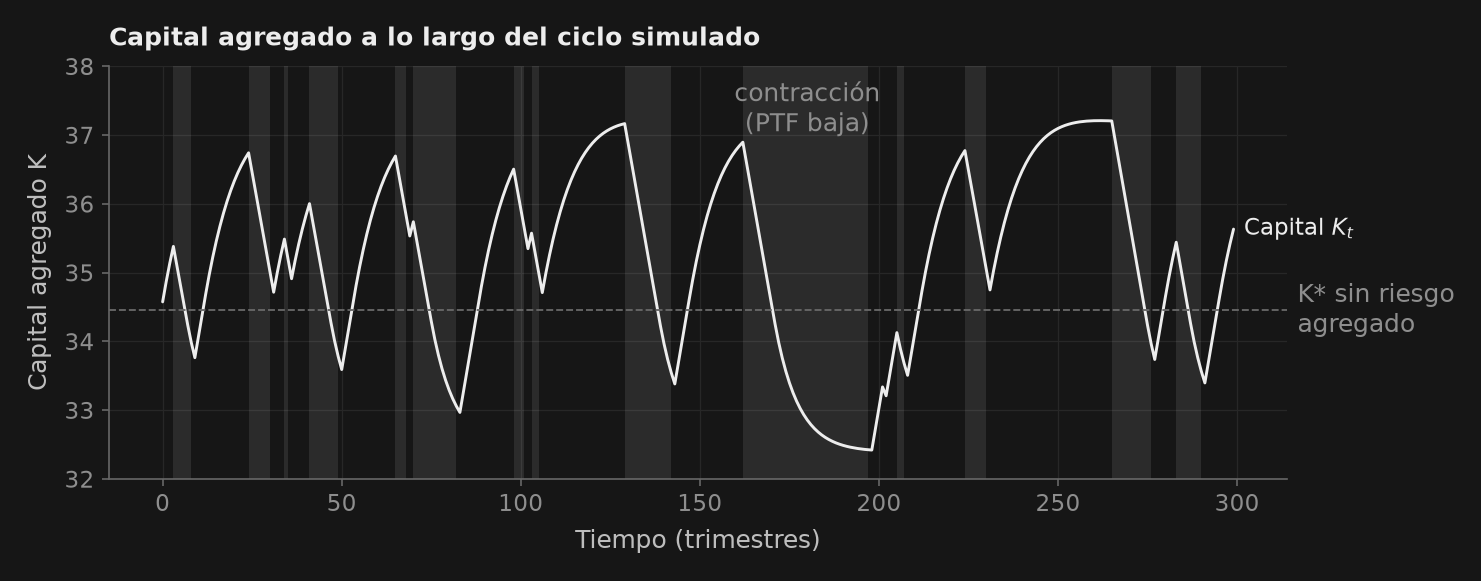

In [5]:
seg = slice(burn, burn + 300)
t = np.arange(300)
low = Z_path[seg] == 0

fig, ax = _nbstyle.figura(figsize="ancho")
ax.plot(t, ks.K_path[seg], color=_nbstyle.TINTA, ls="-", lw=1.4, label="Capital $K_t$")
ax.axhline(ks.no_agg_risk_K, color=_nbstyle.SPINE, linestyle="--", linewidth=0.9)
ax.fill_between(t, 0, 1, where=low, transform=ax.get_xaxis_transform(),
                color=_nbstyle.RECESION, step="mid", linewidth=0)
ax.set_ylim(32, 38)

# Cada objeto lleva su nombre al lado: K* al final de la línea discontinua,
# el sombreado en la contracción más larga
ax.annotate("K* sin riesgo\nagregado", xy=(1, ks.no_agg_risk_K), xycoords=ax.get_yaxis_transform(),
            xytext=(5, 0), textcoords="offset points", ha="left", va="center", color=_nbstyle.NOTA)
bordes = np.flatnonzero(np.diff(np.r_[0, low.astype(int), 0]))
ini, fin = bordes[::2], bordes[1::2]
k = np.argmax(fin - ini)
ax.annotate("contracción\n(PTF baja)", xy=((ini[k] + fin[k]) / 2, 0.97), xycoords=ax.get_xaxis_transform(),
            ha="center", va="top", color=_nbstyle.NOTA)

ax.set_xlabel("Tiempo (trimestres)")
ax.set_ylabel("Capital agregado K")
ax.set_title("Capital agregado a lo largo del ciclo simulado")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 2. Jacobianos en Espacio de Secuencias y el Algoritmo Fake-News (Auclert et al. 2021)

Aunque Krusell y Smith demostraron que la agregación aproximada resuelve los choques de primer momento, simular paneles estocásticos durante miles de periodos es computacionalmente demandante y resulta inviable cuando las restricciones de endeudamiento o fricciones de precios generan no linealidades severas.

Adrien Auclert, Bence Bardóczy, Matthew Rognlie y Ludwig Straub (2021, *Econometrica*) desarrollaron el método de **Jacobianos en Espacio de Secuencias (SSJ)** y el **Algoritmo Fake-News**:
1. **Respuestas de Política en $t=0$ y de Distribución en $t=1$**: Para cualquier innovación en la fecha $s$, se calcula el salto de política $dc_0^s$ y el desplazamiento de distribución $d\mathcal{D}_1^s$ mediante un único paso EGM hacia atrás.
2. **Vectores de Expectativa**: Se propaga la política estacionaria hacia adelante vía la matriz de transición: $\mathcal{E}_t = (\Lambda')^t c_{ss}$.
3. **Matriz Fake-News**: Se construye $\mathcal{F}[0, s] = \mathcal{D}_{ss}' dc_0^s$ y $\mathcal{F}[t, s] = \mathcal{E}_{t-1}' d\mathcal{D}_1^s$.
4. **Recursión del Jacobiano**:
   $$ \mathcal{J}[t, s] = \mathcal{J}[t-1, s-1] + \mathcal{F}[t, s]. $$

Este procedimiento evalúa los Jacobianos intertemporales de consumo $\mathcal{J}_{C,r}$ y $\mathcal{J}_{C,Y}$ en **menos de 0.05 segundos**, suprimiendo por completo los bucles de simulación de Monte Carlo.

Sequence-Space HANK General Equilibrium Solve (Auclert et al. 2021)
Horizon T                       : 40 periods
Aggregate Steady-State MPC      : 0.1027
Steady-State Consumption C_ss   : 0.9998
Government Debt B = A_ss        : 6.5640 (tax rate 0.0656)
Peak Output Response            : -0.004328 (t=0)
Peak Inflation Response         : -0.001493 (t=0)
--------------------------------------------------------------------
MPC by Wealth Decile:
  Decile 1            : 0.6742
  Decile 2            : 0.0883
  Decile 3            : 0.0527
  Decile 4            : 0.0419
  Decile 5            : 0.0362
  Decile 6            : 0.0321
  Decile 7            : 0.0291
  Decile 8            : 0.0266
  Decile 9            : 0.0243
  Decile 10           : 0.0210


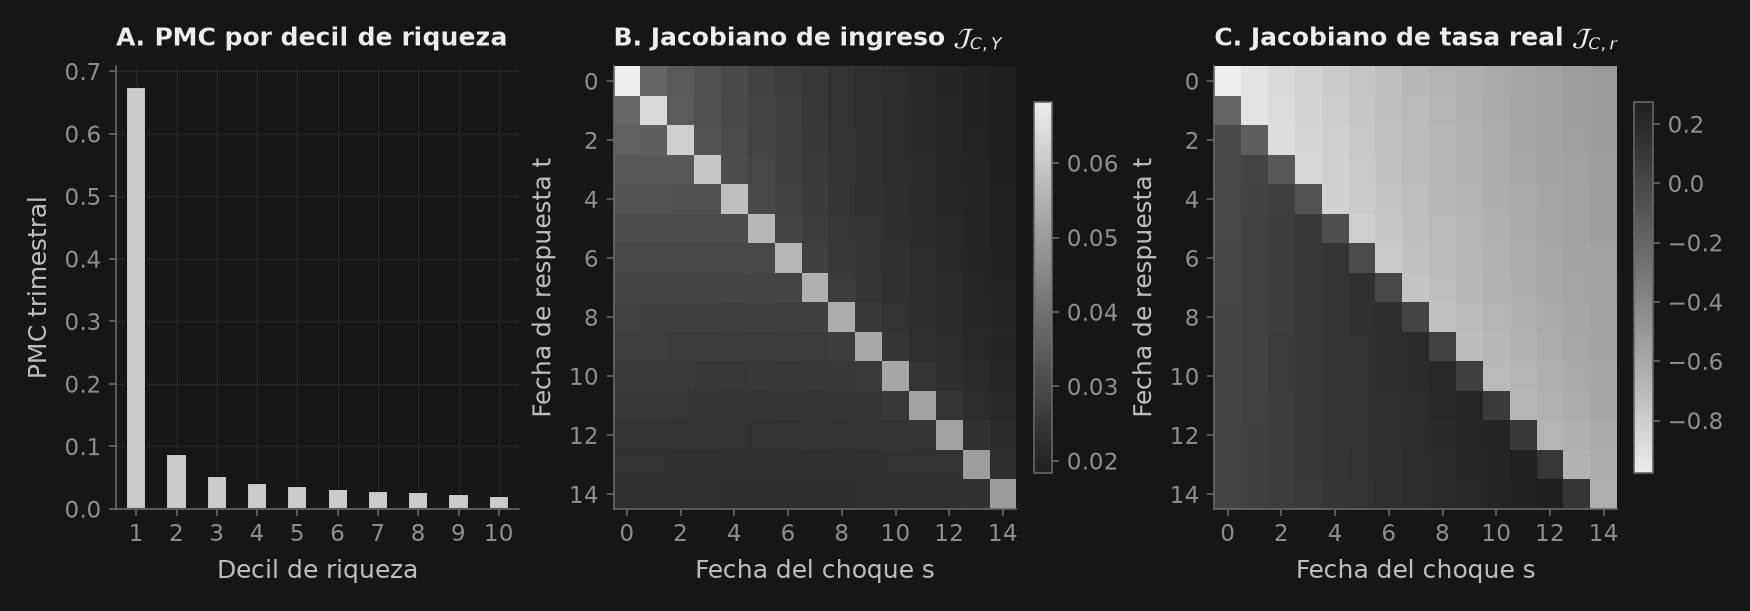

In [6]:
# 1. Resolver el equilibrio estacionario y los Jacobianos en espacio de secuencias
res_ssj = solve_hank_sequence_space(
    T=40,
    beta=0.985,
    gamma=1.0,
    r_ss=0.01,
    phi_pi=1.5,
    kappa=0.1,
    shock_magnitude=0.0025,  # Alza de tasa de 25 pb
    shock_rho=0.7,
    n_a=50,
)
print(res_ssj.summary())
assert res_ssj.ss_converged, "El equilibrio estacionario EGM debe converger"
assert res_ssj.steady_state_mpc > 0.05, "La PMC media debe superar el 5%"

# 2. Visualización: escalera de PMC y Jacobianos en espacio de secuencias
fig, axes = _nbstyle.figura(1, 3)

# Panel A: PMC por decil de riqueza
res_ssj.mpc_distribution.plot(kind="bar", ax=axes[0], color=_nbstyle.BARRA_COLORES[0],
                              edgecolor=_nbstyle.FONDO)
axes[0].set_title("A. PMC por decil de riqueza")
axes[0].set_ylabel("PMC trimestral")
axes[0].set_xticklabels(range(1, 11), rotation=0)
axes[0].set_xlabel("Decil de riqueza")

# Paneles B y C: Jacobianos de ingreso y de tasa real (primeras sub_T fechas)
sub_T = 15
fechas = np.arange(0, sub_T, 2)
im1 = axes[1].imshow(res_ssj.jacobian_c_y[:sub_T, :sub_T], cmap="mav_seq", origin="upper", aspect="auto")
axes[1].set_title(r"B. Jacobiano de ingreso $\mathcal{J}_{C,Y}$")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(res_ssj.jacobian_c_r[:sub_T, :sub_T], cmap="mav_seq_r", origin="upper", aspect="auto")
axes[2].set_title(r"C. Jacobiano de tasa real $\mathcal{J}_{C,r}$")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes[1:]:
    ax.grid(False)
    ax.set_xticks(fechas)
    ax.set_yticks(fechas)
    ax.set_xlabel("Fecha del choque s")
    ax.set_ylabel("Fecha de respuesta t")

plt.show()


### Heterogeneidad Microeconómica, Gradiente de PMC y Amplificación en Equilibrio General

Los paneles anteriores ilustran por qué el espacio de secuencias amplía radicalmente el análisis macroeconómico:

1. **La Escalera de PMC**:
   Los hogares con baja liquidez del primer decil (D1) enfrentan la restricción de endeudamiento activa ($a \ge 0$): su Propensión Marginal a Consumir ante ingresos transitorios es de $0.67$, y ya en D2 y D3 cae a $0.09$ y $0.05$. Los hogares adinerados de los deciles superiores se comportan bajo la hipótesis de ingreso permanente ($PMC \approx 0.02$, del orden de la tasa real $r = 1\%$).

2. **El Multiplicador de Ingreso Intertemporal ($\mathcal{J}_{C, Y}$)**:
   En modelos de agente representativo, el consumo depende exclusivamente de la tasa real intertemporal mediante la ecuación de Euler agregada ($\mathcal{J}_{C,Y} = 0$). En modelos HANK, los hogares con alta PMC generan un potente **multiplicador keynesiano indirecto**: un aumento del ingreso $Y_s$ estimula el consumo corriente, generando elementos fuera de la diagonal positivos en $\mathcal{J}_{C, Y}$ que amplifican las respuestas de política.

## 3. Dinámica de Transición en Equilibrio General: Espacio de Secuencias vs. DSGE Linealizado vs. Choque MIT No Lineal

En el espacio de secuencias, la transición de equilibrio general para cualquier secuencia de choque $\mathbf{\varepsilon}$ se determina por:
$$ (\mathbf{I} - \mathcal{J}_{C,Y} - \mathcal{J}_{C,r} \mathbf{M}_{r,Y}) d\mathbf{Y} = \mathcal{J}_{C,r} d\mathbf{\varepsilon}^m $$
donde $\mathbf{M}_{r,Y}$ recoge la regla de Taylor y la curva de Phillips nuevo-keynesiana:
$$ \mathbf{\pi} = \mathbf{K}_\pi d\mathbf{Y}, \qquad d\mathbf{r} = (\phi_\pi \mathbf{K}_\pi - \mathbf{U}_+ \mathbf{K}_\pi) d\mathbf{Y} + d\mathbf{\varepsilon}^m. $$

Comparamos tres paradigmas computacionales:
1. **HANK Lineal en Espacio de Secuencias**: Resuelto directamente mediante los Jacobianos Fake-News en una inversión matricial.
2. **HANK No Lineal (Broyden)**: Resuelto mediante cuasi-Newton (`solve_nonlinear_transition`), capturando la curvatura no lineal de las políticas y los límites de crédito asimétricos.
3. **DSGE de Agente Representativo Linealizado (RANK)**: El referente con mercados completos donde $\mathcal{J}_{C,Y} = 0$ y $\mathcal{J}_{C,r} = -(\mathbf{I} - \mathbf{U}_+)^{-1}$.

Ojo con la escala de la figura: la transición no lineal usa el choque por omisión del solucionador (100 pb con persistencia 0.7), cuatro veces el alza de 25 pb con la que se calcularon las respuestas lineales HANK y RANK. La distancia entre la curva no lineal y las lineales refleja ante todo ese tamaño de choque; la no linealidad propiamente dicha es la diferencia entre las respuestas lineal y no lineal al mismo choque que imprime el resumen (unos 0.01 pp en el pico del producto).

Non-Linear Sequence-Space HANK Transition Dynamics (Auclert et al. 2021)
Horizon T                       : 40 quarters
Shock Variable                  : R (Monetary Policy Shock)
Shock Peak Magnitude            : 0.010000
Broyden Solver Status           : CONVERGED in 2 iterations
Final Residual ||H||_inf        : 2.846357e-06 (tol 1e-05)
------------------------------------------------------------------------
General Equilibrium Impulse Response Comparison (peak = largest |response|):
  Peak Output Response (Linear)     : -0.017313 at t=0
  Peak Output Response (Non-linear) : -0.017202 at t=0
  Peak Output Difference (NL - Lin) : +0.000111
  Peak Consumption (Linear)         : -0.017313 at t=0
  Peak Consumption (Non-linear)     : -0.017205 at t=0
  Peak Real Rate (Non-linear)       : +0.005369 at t=0
  Cumulative Output Multiplier      : -1.8575


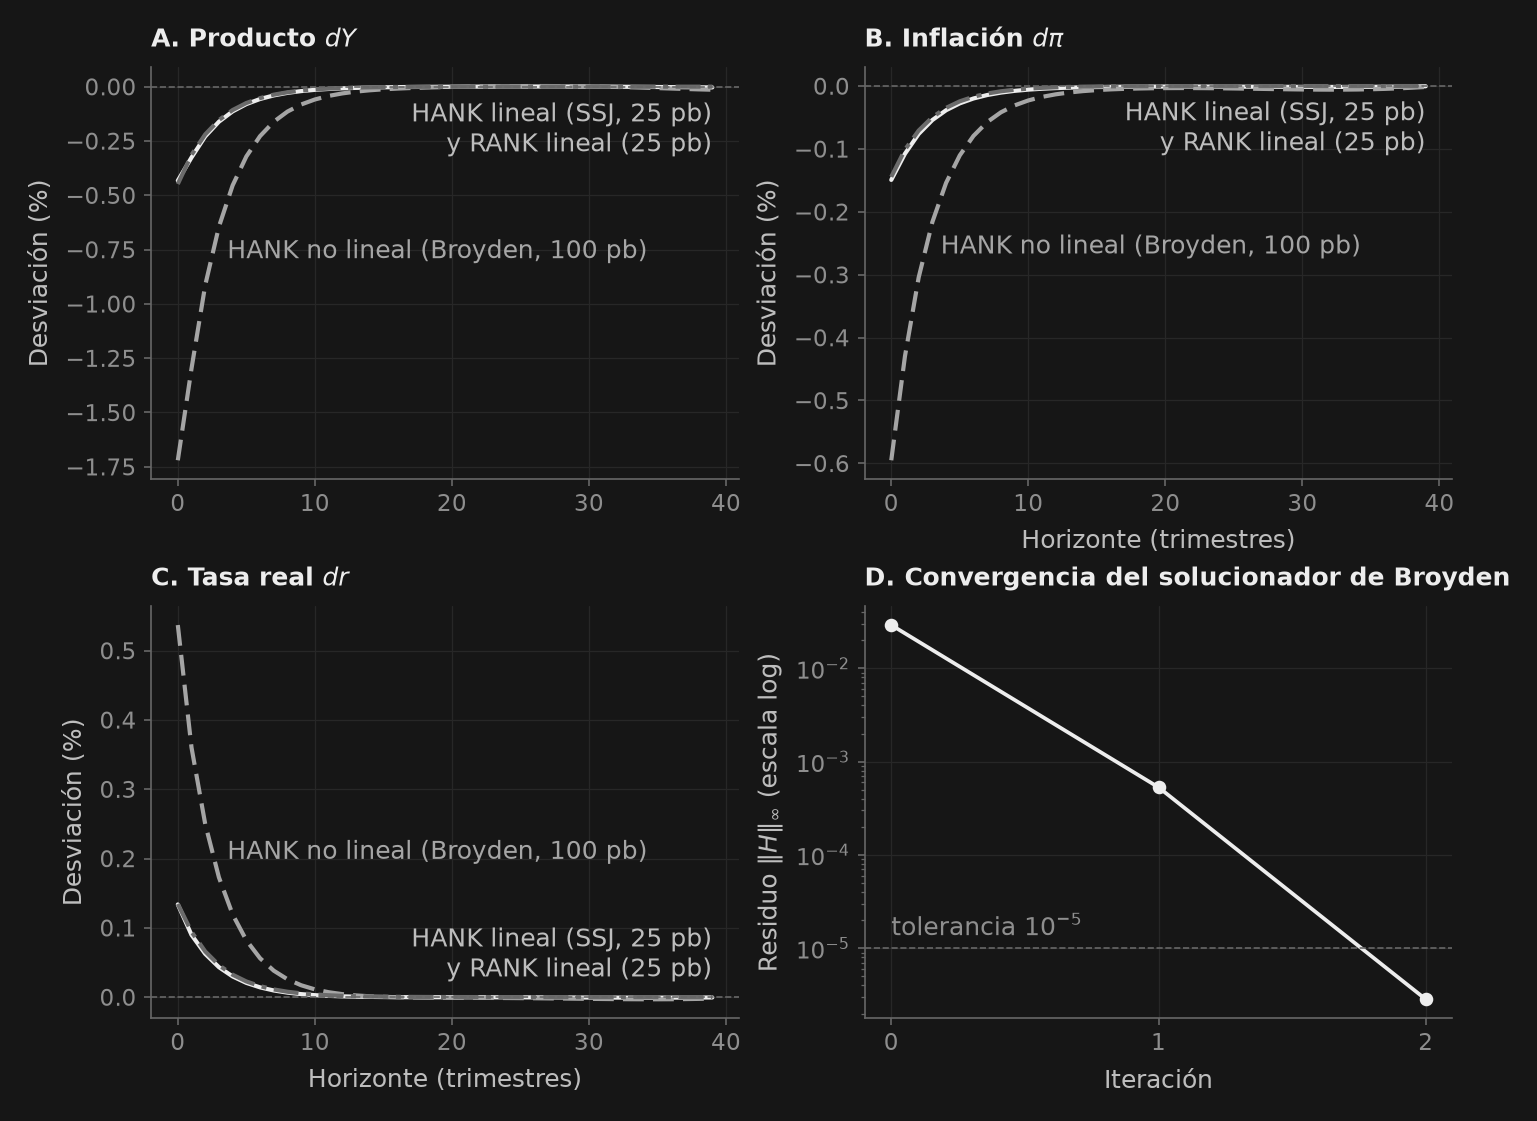

In [7]:
# 1. Transición no lineal de Broyden en espacio de secuencias
res_nonlin = res_ssj.solve_nonlinear(
    shock_var="r",
    horizon=40,
    max_iter=30,
    tol=1e-5,
)
print(res_nonlin.summary())
assert res_nonlin.converged, "El solucionador de Broyden no lineal debe converger"

# 2. Referente DSGE de Agente Representativo (RANK) linealizado en espacio de secuencias
T_sim = 40
beta, phi_pi, kappa = 0.985, 1.5, 0.1
idx = np.arange(T_sim)
lead = idx[None, :] - idx[:, None]
K_pi = np.where(lead >= 0, kappa * beta ** np.maximum(lead, 0), 0.0)
Shift_K_pi = np.zeros((T_sim, T_sim))
Shift_K_pi[:-1, :] = K_pi[1:, :]
M_r_Y = phi_pi * K_pi - Shift_K_pi

Shift = np.zeros((T_sim, T_sim))
Shift[:-1, 1:] = np.eye(T_sim - 1)
J_C_r_rank = -np.linalg.inv(np.eye(T_sim) - Shift)
shock_seq = 0.0025 * (0.7 ** np.arange(T_sim))
dY_rank = np.linalg.solve(np.eye(T_sim) - J_C_r_rank @ M_r_Y, J_C_r_rank @ shock_seq)
dpi_rank = K_pi @ dY_rank
dr_rank = M_r_Y @ dY_rank + shock_seq

# 3. Gráfico de comparación de 4 paneles
fig, axes = _nbstyle.figura(2, 2)
h = np.arange(T_sim)
# El tamaño del choque viaja con el nombre: la trayectoria no lineal usa
# el choque por omisión del solucionador (100 pb) y las dos lineales
# la secuencia de 25 pb construida arriba
nombres = ["HANK lineal (SSJ, 25 pb)", "HANK no lineal (Broyden, 100 pb)", "RANK lineal (25 pb)"]
paneles = [
    (axes[0, 0], "A. Producto $dY$", res_ssj.irf_output, res_nonlin.nonlinear_path, dY_rank),
    (axes[0, 1], r"B. Inflación $d\pi$", res_ssj.irf_inflation, res_nonlin.irf_inflation_nonlinear, dpi_rank),
    (axes[1, 0], "C. Tasa real $dr$", res_ssj.irf_rate, res_nonlin.irf_rate_nonlinear, dr_rank),
]
for ax, titulo, lineal, no_lineal, rank in paneles:
    ax.plot(h, lineal * 100, **_nbstyle.S1)
    ax.plot(h, no_lineal * 100, **_nbstyle.S2)
    ax.plot(h, rank * 100, **_nbstyle.S3)
    ax.axhline(0, color=_nbstyle.SPINE, lw=0.8, linestyle="--")
    ax.set_title(titulo)
    ax.set_ylabel("Desviación (%)")
    # Los nombres van del lado del choque, donde el panel está vacío; las dos
    # respuestas lineales se superponen, así que comparten un rótulo al final
    lado = 1 if no_lineal[0] > 0 else -1
    va = "bottom" if lado > 0 else "top"
    ax.annotate(nombres[1], xy=(3, no_lineal[3] * 100), xytext=(4, 6 * lado), textcoords="offset points",
                ha="left", va=va, color=_nbstyle.S2["color"])
    ax.annotate(f"{nombres[0]}\ny {nombres[2]}", xy=(h[-1], lineal[-1] * 100), xytext=(0, 6 * lado),
                textcoords="offset points", ha="right", va=va, color=_nbstyle.TEXTO)
# B está sobre D, que mide iteraciones: lleva su propio eje x
axes[0, 1].set_xlabel("Horizonte (trimestres)")
axes[1, 0].set_xlabel("Horizonte (trimestres)")

# Panel D: residuos de vaciado de mercado ||H||_inf
axes[1, 1].semilogy(res_nonlin.norm_history, marker="o", color=_nbstyle.TINTA, ls="-", lw=1.8)
axes[1, 1].axhline(1e-5, color=_nbstyle.SPINE, linestyle="--", lw=0.8)
axes[1, 1].annotate("tolerancia $10^{-5}$", xy=(0, 1e-5), xytext=(0, 3), textcoords="offset points",
                    ha="left", va="bottom", color=_nbstyle.NOTA)
axes[1, 1].set_title("D. Convergencia del solucionador de Broyden")
axes[1, 1].set_xlabel("Iteración")
axes[1, 1].set_ylabel(r"Residuo $\|H\|_\infty$ (escala log)")
axes[1, 1].set_xticks(np.arange(len(res_nonlin.norm_history)))

plt.show()


## 4. Validación Empírica y Pruebas de Estrés: Generalización entre Regímenes

Para verificar la robustez de nuestros modelos computacionales, implementamos dos pruebas econométricas y de tensión estructural:

1. **Validación Cruzada Fuera de Muestra de Krusell–Smith**:
   Dividimos la trayectoria simulada en particiones de ajuste (`split`) y prueba, reestimamos la regla log-lineal estrictamente sobre las observaciones de ajuste y evaluamos el $R^2$ fuera de muestra:
   $$ R^2_{\text{prueba}} = 1 - \frac{\sum_{t \in \text{prueba}} (\log K_{t+1} - \widehat{\log K}_{t+1})^2}{\sum_{t \in \text{prueba}} (\log K_{t+1} - \overline{\log K}_{\text{prueba}})^2}. $$

2. **Prueba de Asimetría No Lineal en el Espacio de Secuencias**:
   En modelos DSGE lineales y SSJ lineales, los choques positivos y negativos producen respuestas perfectamente simétricas ($\mathbf{Y}^+ + \mathbf{Y}^- = \mathbf{0}$). Por el contrario, las economías con agentes heterogéneos reales exhiben asimetría dependiente del estado: las restricciones de endeudamiento se vuelven más vinculantes durante las contracciones que en las expansiones. Evaluamos esta asimetría directamente con el algoritmo no lineal de Broyden.

In [8]:
# ==============================================================================
# Parte A: Validación Fuera de Muestra de la Regla de Krusell–Smith
# ==============================================================================
# ← Cambia esta fracción de partición entrenamiento/prueba (ajusta en `split`,
# evalúa en el resto). Mantenlo en (0, 1); la regla debe generalizar en cualquier valor razonable.
split = 0.7
x_all, y_all, z_all = logK[burn:-1], logK[burn + 1:], Z_path[burn:]   # reutilizar ks resuelto
k = int(split * x_all.size)
r2_test = np.empty(2)
for iZ in range(2):                                       # una regla por estado agregado
    fit = z_all[:k] == iZ
    A = np.vstack([np.ones(fit.sum()), x_all[:k][fit]]).T
    coef, *_ = np.linalg.lstsq(A, y_all[:k][fit], rcond=None)
    te = z_all[k:] == iZ                                  # segmento de prueba, mismo estado
    yhat = coef[0] + coef[1] * x_all[k:][te]
    yt = y_all[k:][te]
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2_test[iZ] = 1.0 - float(np.sum((yt - yhat) ** 2)) / ss_tot
print(f"Krusell-Smith split={split}: R² fuera de muestra por estado = {np.round(r2_test, 5)}  "
      f"(dentro de muestra {np.round(ks.r_squared, 5)})")
assert r2_test.min() > 0.9, r2_test     # la regla generaliza: el ajuste se mantiene alto

# ==============================================================================
# Parte B: Prueba de Asimetría No Lineal en el Espacio de Secuencias
# ==============================================================================
shock_pos = +0.005 * (0.7 ** np.arange(40))  # +50 pb alza de tasa
shock_neg = -0.005 * (0.7 ** np.arange(40))  # -50 pb recorte de tasa
nl_pos = solve_nonlinear_transition(res_ssj, shock_pos, shock_var="r", horizon=40)
nl_neg = solve_nonlinear_transition(res_ssj, shock_neg, shock_var="r", horizon=40)

# En un modelo lineal, pos + neg == 0 exactamente. En HANK no lineal surge asimetría:
nonlin_sum = nl_pos.nonlinear_path + nl_neg.nonlinear_path
max_asymmetry = float(np.max(np.abs(nonlin_sum)))
print(f"Asimetría no lineal SSJ (||Y_+ + Y_-||_inf): {max_asymmetry:.6e}")
assert nl_pos.converged and nl_neg.converged, "Ambas trayectorias no lineales deben converger"
assert max_asymmetry > 1e-5, f"Asimetría no lineal demasiado pequeña: {max_asymmetry:.2e}"

Krusell-Smith split=0.7: R² fuera de muestra por estado = [0.99869 0.99929]  (dentro de muestra [0.99867 0.99929])
Asimetría no lineal SSJ (||Y_+ + Y_-||_inf): 5.527304e-05


### Conclusiones Econométricas y Límites Metodológicos de la Agregación Aproximada

La validación empírica y las comparaciones en espacio de secuencias ofrecen lecciones macroeconómicas fundamentales:

1. **Robustez de la Agregación Aproximada para Choques de Nivel**:
   Al variar la fracción de entrenamiento (por ejemplo, `split = 0.40`), el ajuste fuera de muestra se mantiene por encima de $0.998$. Esta estabilidad ocurre porque la distribución de la riqueza entre los agentes no restringidos varía muy suavemente ante choques simétricos de primer momento de PTF.

2. **Ruptura ante Choques de Incertidumbre de Segundo Momento**:
   ¿Por qué se degradaría la agregación aproximada si la economía experimentara un **choque de incertidumbre** (Bloom 2009)? Cuando la incertidumbre idiosincrásica $\sigma_z^2$ se dispara, los motivos de ahorro precautorio se intensifican, desplazando masa hacia la restricción de endeudamiento $a=0$ donde las funciones de política son altamente no lineales. Con dispersión transversal cambiante en el tiempo, un único escalar $K_t$ deja de ser un estadístico suficiente y los momentos superiores se activan como determinantes del ahorro agregado.

3. **La Ventaja Computacional de los Jacobianos en Espacio de Secuencias**:
   Mientras que Krusell–Smith requería horas de simulación de Monte Carlo en su planteamiento original (y segundos con aceleración de Howard), el método de Jacobianos en Espacio de Secuencias de Auclert et al. (2021) resuelve la transición lineal exacta en milisegundos y las transiciones no lineales de Broyden en segundos. Esto permite incorporar reglas monetarias y fiscales realistas, múltiples activos y fricciones financieras en modelos macroeconómicos cuantitativos con agentes heterogéneos.

4. **Hacia los Siguientes Módulos**:
   En el próximo módulo (**T03_B**), abordaremos el modelado econométrico de la heterocedasticidad condicional y la volatilidad financiera mediante procesos GARCH y GJR-GARCH, como antesala al estudio detallado de la distribución de riqueza en el **Tema 6**.